# TP1 (a completer) : K-means + ACP — *Wine*

Remplacez chaque `...` et chaque `# TODO`. Le corrige est dans
`../notebooks/TP1_kmeans_acp.ipynb` (a ne consulter qu'en dernier recours).

**Objectif.** Retrouver, par clustering, les **3 cepages** de 178 vins decrits
par 13 mesures chimiques, sans utiliser l'etiquette ; puis valider et qualifier.

In [2]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [3]:
from sklearn.datasets import load_wine
ds = load_wine(as_frame=True)
X = ds.data
cepage = ds.target      # garde de cote pour la validation
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 1. Exploration
**Consigne.** Affichez la moyenne et l'ecart-type de chaque variable pour
constater les differences d'echelle.

In [4]:
X.describe().loc[['mean', 'std']]

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474


On ce rend vite compte que les moyenne et écart type entre les moyenne et les ecart-type sont important au sein des variables.

## 2.a Standardisation
**Consigne.** Standardisez `X` (moyenne 0, ecart-type 1) avec `StandardScaler`.

In [5]:
from sklearn.preprocessing import StandardScaler

# TODO : creer X_std en standardisant X
scaler = StandardScaler()
X_std = scaler.fit_transform(X)
print(X_std.mean(axis=0))
print(X_std.std(axis=0))

[-8.38280756e-16 -1.19754394e-16 -8.37033314e-16 -3.99181312e-17
 -3.99181312e-17  0.00000000e+00 -3.99181312e-16  3.59263181e-16
 -1.19754394e-16  2.49488320e-17  1.99590656e-16  3.19345050e-16
 -1.59672525e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Le but de cette manipulation est de faire en sorte que si une variable a une moyenne a 10 et que une autre a 1000 est que ces variable a 10 ne soit pas écrasé par les variable a 1000 ainsi les variable peuvent avoir une importance similaire dans les prochain calcule afin de pouvoir êtres utilisé de manière optimale

## 2.b Choisir k
**Consigne.** Pour `k` de 2 a 8, entrainez un `KMeans` et stockez l'inertie
(`.inertia_`) et la silhouette (`silhouette_score`). Tracez les deux courbes et
deduisez `k_best` (k qui maximise la silhouette).

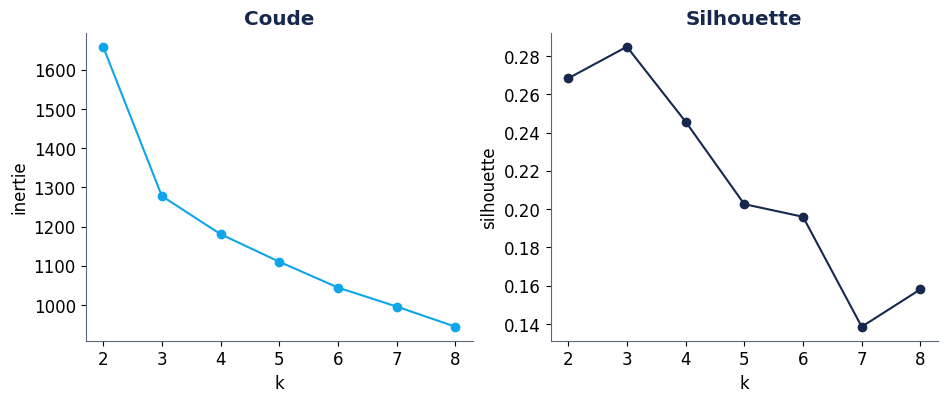

k retenu : 3


In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inerties, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_std)
    inerties.append(km.inertia_)        # TODO : inertie
    silhouettes.append(silhouette_score(X_std, km.labels_))     # TODO : silhouette

# on cherche l'indice du max dans la liste que l'on vient de générer
k_best = list(ks)[np.argmax(silhouettes)]                    # TODO : k de meilleure silhouette

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(list(ks), inerties, "-o", color=ACCENT)
ax1.set(title="Coude", xlabel="k", ylabel="inertie")
ax2.plot(list(ks), silhouettes, "-o", color=NAVY)
ax2.set(title="Silhouette", xlabel="k", ylabel="silhouette")
plt.show()
print("k retenu :", k_best)

On remarque que pour le Coude la valeur qui a une chute la plus importante est a k = 3 et si on regarde pourla silhouette on remarque que au meme k = 3 la silhouette est la plus importante nous démontrant clairement un lien a k = 3.

Donc au final on peut en conclure que les deux méthode converge vers le même K, 3 est donc le nombre optimal au vue de ces graphique.

## 3. Evaluation + validation
**Consigne.** Entrainez le modele final avec `k_best`. Affichez l'inertie, la
silhouette, puis **validez** : calculez l'`adjusted_rand_score` entre `cepage` et
les clusters, et affichez le `pd.crosstab`.

In [7]:
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=k_best, n_init=10, random_state=0).fit(X_std)
labels = km.labels_

# TODO : afficher silhouette et adjusted_rand_score(cepage, labels)
print(km.inertia_) #inertie
print(silhouette_score(X_std, labels)) #silhouette
print(adjusted_rand_score(cepage, labels)) #adjusted rand score

# TODO : tableau croise clusters x cepage
pd.crosstab(labels, cepage, rownames=['Cluster'], colnames=['Cépage'])

1277.928488844643
0.2848589191898987
0.8974949815093207


Cépage,0,1,2
Cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


1277.93 : C'est la somme des distances au carré par rapport aux centres de leurs clusters respectifs.

0.285 : c'est le score maximal possible pour ce jeu de données , il représente la séparation globale correcte des groupes sans trop de chevauchement.

0.897 : L'ARI compare tes clusters avec la vérité terrain , plus le score est proche de 1 plus il est proche de la réalité. Dans notre cas on se rend compte que l'algorithme K-means a réussi à ce raprocher sans supervision a un ARI extrement proche de 1.

Ce tableau croisé nous montre que sur 178 vins, il n'y a que 6 erreurs de classement au total. Realisé sur le Cépage 2.


## 4. Visualisation ACP
**Consigne.** Projetez `X_std` en 2D avec `PCA(n_components=2)`, puis tracez un
nuage de points colore par cluster (ajoutez les centres si vous le souhaitez).

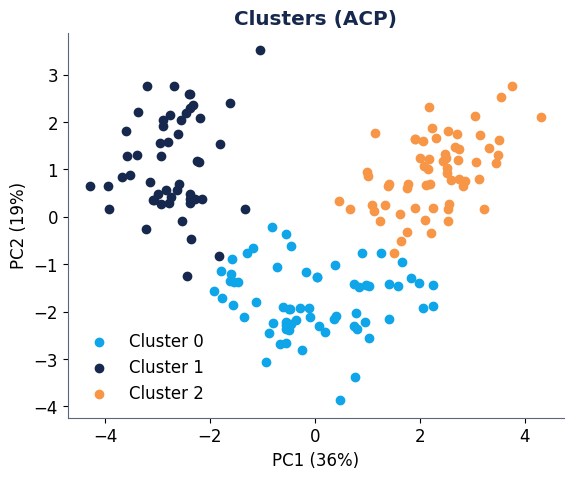

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(X_std)         # TODO : fit_transform(X_std)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(6.4, 5))
for c in sorted(np.unique(labels)):
    m = labels == c
    # TODO : scatter des points du cluster c (coords[m, 0], coords[m, 1])
    ax.scatter(coords[m, 0], coords[m, 1], label=f"Cluster {c}", color=PALETTE[c])

ax.set(title="Clusters (ACP)", xlabel=f"PC1 ({var[0]:.0%})", ylabel=f"PC2 ({var[1]:.0%})")
ax.legend(frameon=False)
plt.show()

Le graphique ACP nous montre bien une delimitaion entre les differents cluester.
Les frontières entre le Cluster 0 (bleu), le Cluster 1 (bleu foncé) et le Cluster 2 (orange) sont bien définies. Les points d'une même couleur sont bien regroupés ensemble.

Ce graphique nous montre pourquoi le knmins a un ARI aussi proche 1 car les cluester sont bien distinct en terme de proximité de leurs cluester.

## 5 & 6. Integration + qualification
**Consigne.** Ajoutez la colonne `cluster` a une copie de `X`, puis calculez le
profil moyen (`groupby`) des variables `alcohol`, `color_intensity`,
`flavanoids`, `proline` par cluster. Commentez les profils.

In [9]:
vins = X.copy()
vins["cluster"] = labels
cles = ["alcohol", "color_intensity", "flavanoids", "proline"]
# TODO : profil moyen par cluster
profil = vins.groupby("cluster")[cles].mean()
profil

,alcohol,color_intensity,flavanoids,proline
cluster,,,,
0,12.250923,2.973077,2.050000,510.169231
1,13.134118,7.234706,0.818824,619.058824
2,13.676774,5.453548,3.003226,1100.225806


le tableau affiche les moyennes des quatre caractéristiques clés pour chaque groupe.

Cluster 1 :Ce groupe possède le taux d'alcool le plus faible (12.25%) et une intensité colorante très basse (2.97) et sa teneur en proline (510.17) est également la plus basse.

Cluster 2 :Ce groupe a la plus grand scores sur l'intensité colorante (7.23), aussi ils ont le taux de flavanoïdes le plus faible (0.82) et leur taux d'alcool est modéré (13.13%).

Cluster 3 : Ce groupe affiche la teneur en alcool la plus forte (13.68%) et une quantité de loin superieur aux autre pour la proline (1100.23) de plus ils sont aussi la plus aute valeur en flavanoïdes (3.00).

Synthese :    

Pourquoi knmins : Le nombre de clusters idéal est 3. La courbe du coude montre une forte décélération de la baisse de l'inertie exactement après k=3, alors que le score de silhouette y atteint son maximum global absolu (0.285).

Résultat ARI :L'ARI obtenu est extreément proche de 1  (0.897). Le tableau croisé montre que le partitionnement automatique correspond presque aux vrais cépages d'origine (seulement 6 erreurs d'affectation sur 178 vins).

Et enfin via le graphique on se rend réellement compte que les vin sont bien séparé en groupe distinct expliquant notre résultat de 0.897 en ARI.



## A rendre
- Le `k` retenu et sa justification (coude + silhouette).
- L'ARI obtenu et votre interpretation du tableau croise.
- Une phrase de qualification par cluster.

**Bonus.** Refaites l'analyse **sans** standardisation : que devient l'ARI ?

Bonus si on refait l'analyse sans standardisation , les valeur de proline qui tourne autour de 1000 vont écrasé les autre valeurs et ont se retrouvera avec une ARI basé pratiquement exclusivement sur la  proline et donc ont perd les variation du aux autre valeur comme le taux alcool et autre.

Donc il important voir obligatoir si on veut que l'analyse soit correcte de faire cette étape de standardisation.

## 7. Aller plus loin : le clustering hierarchique (CAH)

K-means n'est pas la seule methode de clustering. La **Classification Ascendante
Hierarchique (CAH)** procede autrement :

1. au depart, **chaque vin est seul** dans son cluster ;
2. a chaque etape, on **fusionne les deux clusters les plus proches** ;
3. on continue jusqu'a n'avoir **qu'un seul cluster**.

L'historique des fusions se lit sur un **dendrogramme** : on le "coupe" a la
hauteur voulue pour obtenir k clusters. Avantage : pas besoin de fixer k a
l'avance, et la structure est visible.

**Consigne.** Tracez le dendrogramme (methode de Ward sur `X_std`), puis
recuperez 3 clusters avec `AgglomerativeClustering` et comparez-les aux clusters
K-means et aux vrais cepages (ARI).

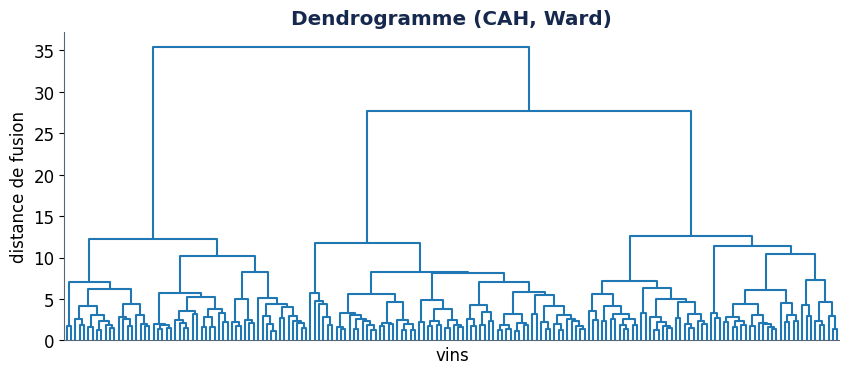

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Matrice de liaison (linkage) par la methode de Ward sur les donnees standardisees
Z = linkage(X_std, method="ward")                    # TODO : linkage(X_std, method="ward")

# 2. Dendrogramme
fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, no_labels=True, color_threshold=0, ax=ax)
ax.set(title="Dendrogramme (CAH, Ward)", xlabel="vins", ylabel="distance de fusion")
plt.show()

Le dendrogramme représente graphiquement les fusion successive des vins selon le critère de Ward. En observant l'arbre de bas en haut, on constate que les "branches" se regroupent très bas en petits groupes, puis fusionnent plus haut.
Et surtout on distingue bien comme avec les knmins plus proche voisin bien 3 groupe distinct.

In [13]:
from sklearn.cluster import AgglomerativeClustering

# 3. Couper l'arbre pour obtenir 3 clusters
cah = AgglomerativeClustering(n_clusters=3, linkage="ward")
labels_cah = cah.fit_predict(X_std)             # TODO : cah.fit_predict(X_std)

# 4. Comparer : CAH vs K-means, et CAH vs vrais cepages (adjusted_rand_score)
# TODO : afficher les deux ARI
print(adjusted_rand_score(labels, labels_cah)) # knmins
print(adjusted_rand_score(cepage, labels_cah)) # CAH
pd.crosstab(labels_cah, cepage, rownames=["CAH"], colnames=["cepage reel"])

0.8529841218194189
0.7899332213582837


cepage reel,0,1,2
CAH,,,
0,0,58,0
1,0,8,48
2,59,5,0


On remarque tout de suite que le score ARI du CAH est inferieur a celuit knmin plus proche voisin une difference de 0.07 environ. De plus dans le tableaux croisé on voit bien que CAH c'est trompé 13 fois au total encore sur le cluster 2 ce qui est plus de deux fois plus que knmins


En conclusion ci on doit choisire l'un des deux , on doit favorisé le knmins plus prochje voisin étant celuit avec le ARI le plus proche de 1.

## A rendre
- Le `k` retenu et sa justification (coude + silhouette).
- L'ARI obtenu et votre interpretation du tableau croise.
- Une phrase de qualification par cluster.
- La comparaison **K-means vs CAH** (ARI) et ce que montre le dendrogramme.

**Bonus.** Refaites l'analyse **sans** standardisation : que devient l'ARI ?